# Goals and Structure

We first discuss the goals. The central objective is to be able to accurately predict fails. We will try to keep the model as simple as possible. This means using as little information as possible as well. 

We will broadly structure the model as a few different sections. 

1. Load the libraries and data
2. Exploratory analysis
3. Feature Selection and Preprocessing
4. Training
5. Evaluation


# 1. Libraries and Data
We first load the required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
data_file = "secom/secom.data"
label_file = "secom/secom_labels.data"

df_data = pd.read_csv(data_file, sep = " ",  header = None)
df_labels = pd.read_csv(label_file, sep = " ", header = None, names = ["Label", "Timestamp"])

data = pd.concat([df_data,df_labels], axis = 1)

print(data.shape)

data.head()

# So apparently even though the documentation states that there are 591 columns in the secom.data file, there isn't
# Checked a bunch of different ways, on here as well as counting the spaces, etc. there's 589 spaces

(1567, 592)


,0,1,2,3,4,5,6,7,8,9,...,582,583,584,585,586,587,588,589,Label,Timestamp
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1,19/07/2008 11:55:00
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1,19/07/2008 12:32:00
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1,19/07/2008 13:17:00
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1,19/07/2008 14:43:00
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1,19/07/2008 15:22:00


In [9]:
print(data.dtypes)

print(data.describe())

print(data.groupby('Label').size())

0            float64
1            float64
2            float64
3            float64
4            float64
              ...   
587          float64
588          float64
589          float64
Label          int64
Timestamp     object
Length: 592, dtype: object
                 0            1            2            3            4  \
count  1561.000000  1560.000000  1553.000000  1553.000000  1553.000000   
mean   3014.452896  2495.850231  2200.547318  1396.376627     4.197013   
std      73.621787    80.407705    29.513152   441.691640    56.355540   
min    2743.240000  2158.750000  2060.660000     0.000000     0.681500   
25%    2966.260000  2452.247500  2181.044400  1081.875800     1.017700   
50%    3011.490000  2499.405000  2201.066700  1285.214400     1.316800   
75%    3056.650000  2538.822500  2218.055500  1591.223500     1.525700   
max    3356.350000  2846.440000  2315.266700  3715.041700  1114.536600   

            5            6            7            8            9  ...  \
c

From these descriptions we can observe a few things. The first and most important thing is that the dataset is highly imbalanced.

In particular, only 1 in 15 of the data are fails and the rest are successes. 

From the source of the data, we also know that there are many NaN values, so we should check roughly how many. 

In [ ]:
print(data.apply(lambda column :column.isnull().sum()).sum()*100/data.size) # missing data percentage
print(data.apply(lambda column :column.hasnans, axis = 1).sum()) # number of entries that have missing data

4.522219251798065
1567


Taken together this tells us that 4.5% of the dataset is NaN and every single entry/row has a NaN.
This effectively rules out dropping any row that has a NaN

We should take a closer look at this. One way this could be done is through a heatmap. 

<Axes: >

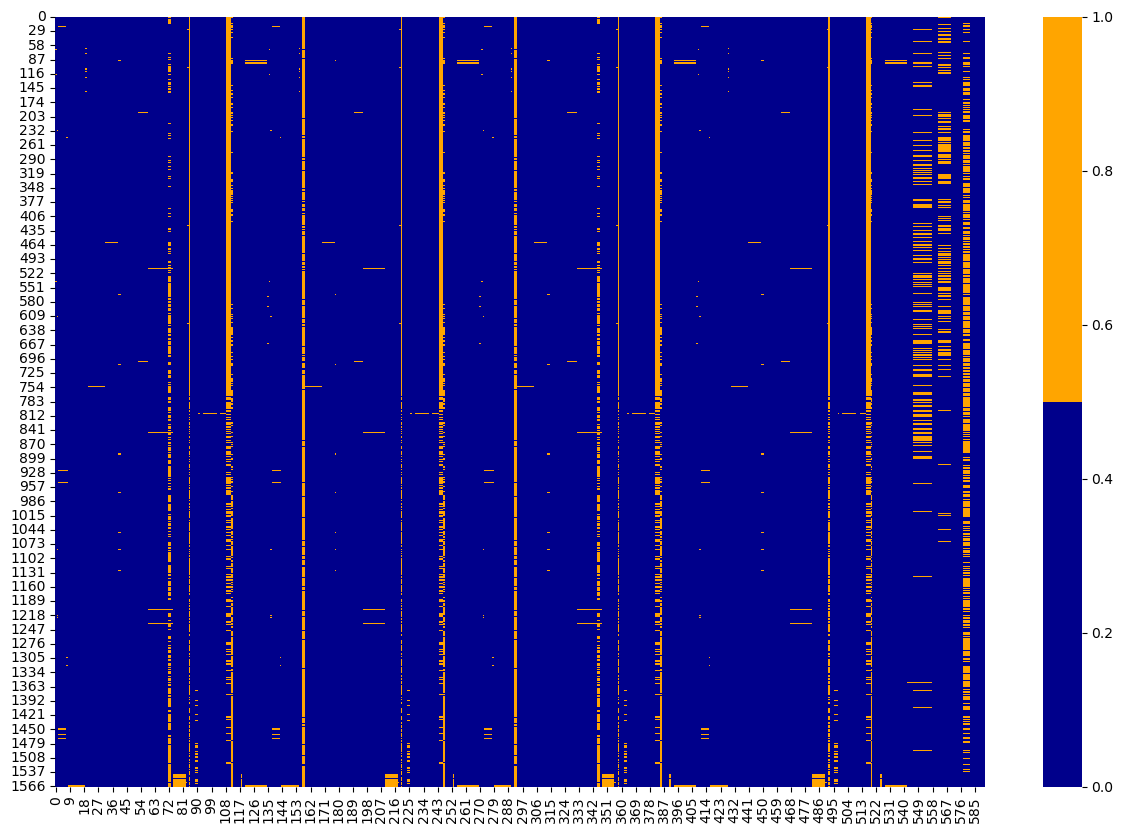

In [ ]:
plt.figure(figsize=(15,10))

colours = ['#00008B', 'orange'] # I like dark blue and orange and they're pretty easy to see
sns.heatmap(data.isnull(), cmap = colours)

<Axes: >

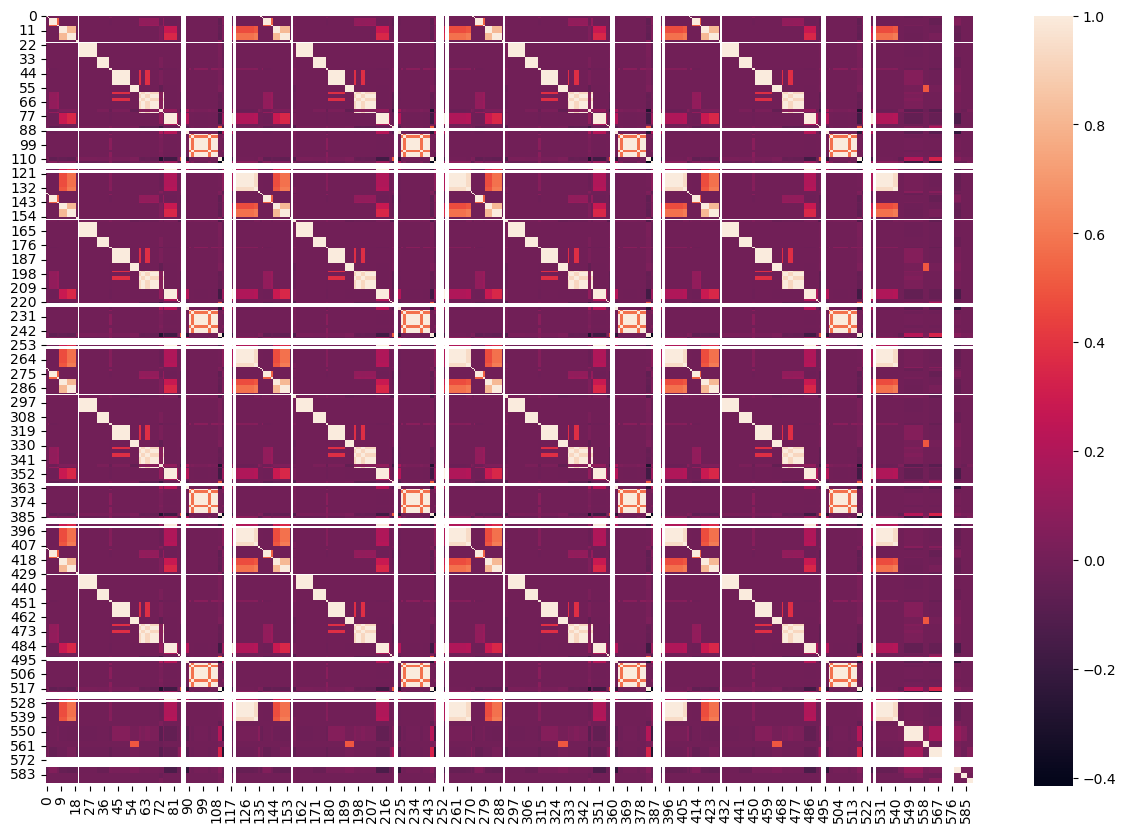

In [25]:
# We can also print out a heatmap of the nullity correlations,
# which shows how the missing values are correlateed across features

plt.figure(figsize=(15,10))

sns.heatmap(data.isnull().astype(int).corr())

In [32]:
import missingno as msno
# A lot of the above work could have been done with msno, but I found about this afterwards